In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# ML
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
golden_eye_data_path = "CSE-CIC-IDS2018/02-15-2018.csv"
#slow_http_data_path = "CSE-CIC-IDS2018/02-16-2018.csv"

#data_path = "CSE-CIC-IDS2018/02-15-2018.csv"
#data_path = "sampled_output/sampled_combined.csv"
#golden_eye_dataset = pd.read_csv(golden_eye_data_path)
#slow_http_dataset = pd.read_csv(slow_http_data_path)
#dataset = pd.concat([golden_eye_dataset, slow_http_dataset], ignore_index=True)

dataset = pd.read_csv(golden_eye_data_path)

print("Shape:", dataset.shape)
display(dataset.head())
#one row has a label observation instead of the correct attack attribute
#thus this takes 10x as long as it should :(
dataset = dataset[dataset['Label'] != 'Label']

# Suppose your label column is named 'label'
benign = dataset[dataset['Label'] == 'Benign']

# Randomly sample half of them
benign_half = benign.sample(frac=0.75, random_state=42)

# Drop those sampled rows from the original dataframe
dataset = dataset.drop(benign_half.index)

dataset.info()

Shape: (1048575, 80)


,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,0,0,15/02/2018 08:25:18,112641158,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320579.0,7.042784e+02,56321077,56320081,Benign
1,22,6,15/02/2018 08:29:05,37366762,14,12,2168,2993,712,0,...,32,1024353.0,649038.754495,1601183,321569,11431221.0,3.644991e+06,15617415,8960247,Benign
2,47514,6,15/02/2018 08:29:42,543,2,0,64,0,64,0,...,32,0.0,0.000000,0,0,0.0,0.000000e+00,0,0,Benign
3,0,0,15/02/2018 08:28:07,112640703,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320351.5,3.669884e+02,56320611,56320092,Benign
4,0,0,15/02/2018 08:30:56,112640874,3,0,0,0,0,0,...,0,0.0,0.000000,0,0,56320437.0,7.198347e+02,56320946,56319928,Benign


<class 'pandas.core.frame.DataFrame'>
Index: 550537 entries, 1 to 1048571
Data columns (total 80 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Dst Port           550537 non-null  int64  
 1   Protocol           550537 non-null  int64  
 2   Timestamp          550537 non-null  object 
 3   Flow Duration      550537 non-null  int64  
 4   Tot Fwd Pkts       550537 non-null  int64  
 5   Tot Bwd Pkts       550537 non-null  int64  
 6   TotLen Fwd Pkts    550537 non-null  int64  
 7   TotLen Bwd Pkts    550537 non-null  int64  
 8   Fwd Pkt Len Max    550537 non-null  int64  
 9   Fwd Pkt Len Min    550537 non-null  int64  
 10  Fwd Pkt Len Mean   550537 non-null  float64
 11  Fwd Pkt Len Std    550537 non-null  float64
 12  Bwd Pkt Len Max    550537 non-null  int64  
 13  Bwd Pkt Len Min    550537 non-null  int64  
 14  Bwd Pkt Len Mean   550537 non-null  float64
 15  Bwd Pkt Len Std    550537 non-null  float64
 16  Flow B

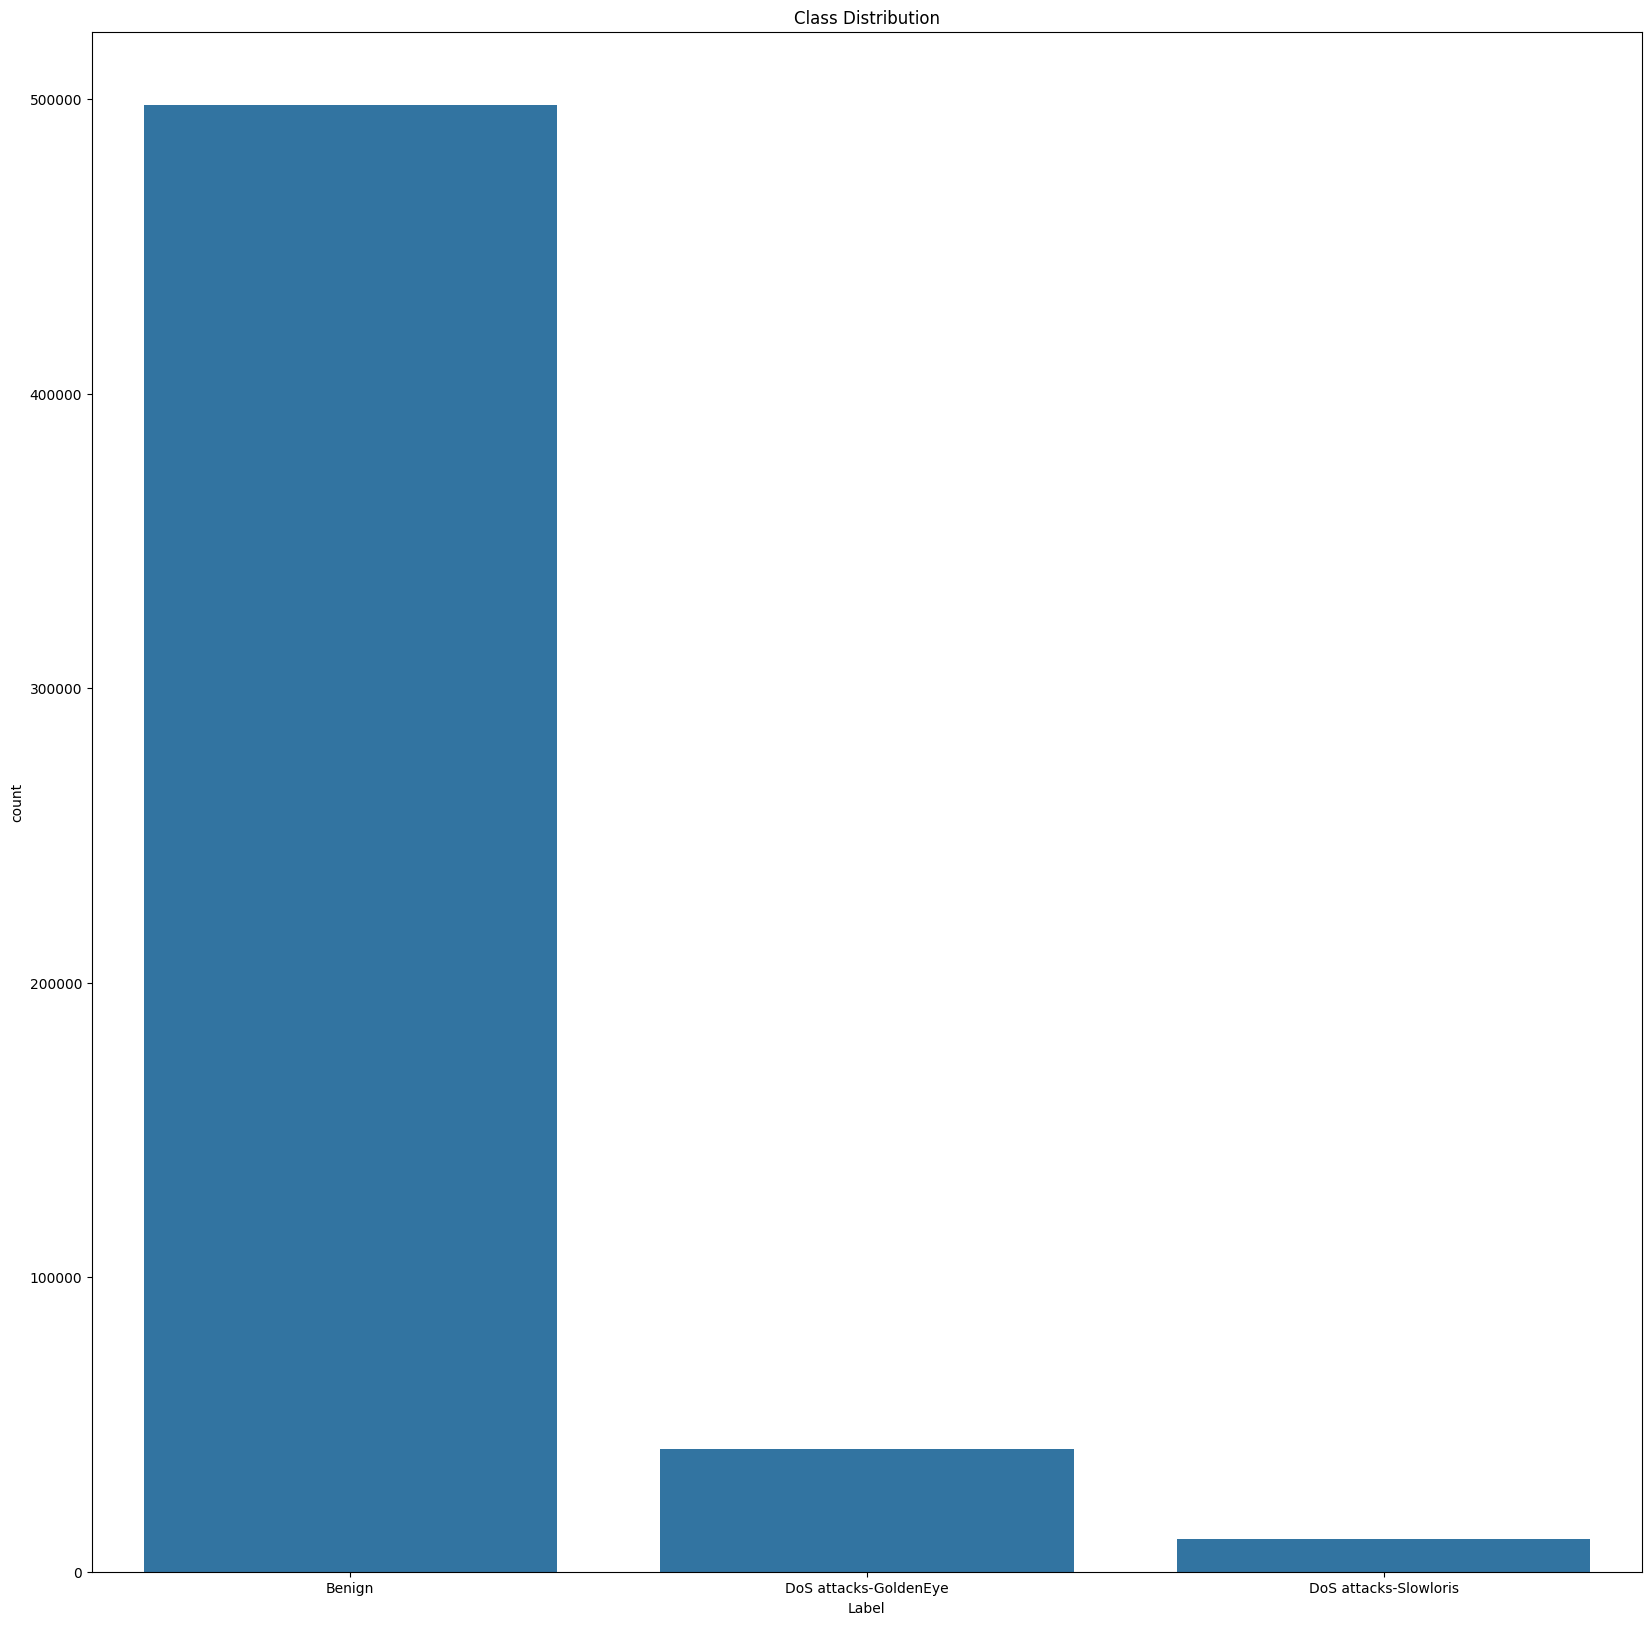

In [8]:
plt.figure(figsize=(20,20))
sns.countplot(x=dataset['Label'])
plt.title("Class Distribution")
plt.show()

In [9]:
drop_cols = ['Dst Port', 
             'Protocol',
             'Timestamp',
             'Flow IAT Mean',
             'Flow IAT Std',
             'Flow IAT Max',
             'Flow IAT Min',
             'Fwd PSH Flags',
             'Bwd PSH Flags',
             'Fwd URG Flags',
             'Bwd URG Flags',
             'Fwd Header Len',
             'Bwd Header Len',
             'Fwd Pkts/s',
             'Bwd Pkts/s',
             'Pkt Len Var',
             'Down/Up Ratio',
             'Pkt Size Avg',
             'Fwd Seg Size Avg',
             'Bwd Seg Size Avg',
             'Fwd Byts/b Avg',
             'Fwd Pkts/b Avg',
             'Bwd Byts/b Avg',
             'Bwd Pkts/b Avg',
             'Fwd Act Data Pkts',
             'Fwd Seg Size Min',
             'Active Mean',
             'Active Std',
             'Active Max',
             'Active Min',
             'Idle Mean',
             'Idle Std',
             'Idle Max',
             'Idle Min',
             'Bwd Blk Rate Avg',
             'Fwd Blk Rate Avg']

reduced_dataset = dataset.drop(columns=drop_cols)

# replace infinity value as null value
reduced_dataset = reduced_dataset.replace(["Infinity", "infinity"], np.inf)
reduced_dataset = reduced_dataset.replace([np.inf, -np.inf], np.nan)
# drop all null values
reduced_dataset.dropna(inplace=True)

target = 'Label'
X = reduced_dataset.drop(columns=[target])
y = reduced_dataset[target]
print(X.columns)


Index(['Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts',
       'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
       'Flow Pkts/s', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Pkt Len Min',
       'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'FIN Flag Cnt',
       'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt',
       'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Subflow Fwd Pkts',
       'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts',
       'Init Fwd Win Byts', 'Init Bwd Win Byts'],
      dtype='object')


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Report:")
print(classification_report(y_test, y_pred_dt))

KeyboardInterrupt: 

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Report:
                          precision    recall  f1-score   support

                  Benign       1.00      1.00      1.00    286965
   DoS attacks-GoldenEye       1.00      1.00      1.00      8302
        DoS attacks-Hulk       1.00      1.00      1.00     92382
DoS attacks-SlowHTTPTest       1.00      1.00      1.00     27978
   DoS attacks-Slowloris       1.00      0.99      0.99      2198

                accuracy                           1.00    417825
               macro avg       1.00      1.00      1.00    417825
            weighted avg       1.00      1.00      1.00    417825



In [ ]:
dt_model_path = "models/dt_ids_model.pkl"
with open(dt_model_path, "wb") as f:
    pickle.dump(dt, f)

In [ ]:
rf_model_path = "models/rf_ids_model.pkl"
with open(rf_model_path, "wb") as f:
    pickle.dump(rf, f)